---
title: Dataset Construction (using virtualization!)
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

This notebook demonstrates some of our software workflows that can be used to construct tabular datasets of Antarctic AR events, including MERRA-2 streaming, specifically using the new `earthaccess` virtualization features to (hopefully) speed up the creation of our datasets.

**This notebook is having memory blowups when trying to load the entire virtualized store. Need to find a better way to only load what we need. In the meantime, will benchmark on a smaller subset of ARs.**

:::{attention}
If running the streaming workflows on CryoCloud, make sure to choose a server with enough RAM, as well as CPUs for parallelization. The RAM used by this notebook should not exceed 15GB at any point during the streaming loop. We ran this notebook on CryoCloud's 29GB server, which has ~4 CPUs available at all times.
:::

## Setup

First, we'll load up any packages and modules we might need.

In [1]:
# load external packages
import os
import pandas as pd
import xarray as xr
from pathlib import Path
import earthaccess
import ray
from tqdm import tqdm
from huggingface_hub import login, HfApi
import logging
import sys
from datetime import datetime, timedelta
import fsspec
import zarr

In [2]:
# load artools
import artools
from artools.loading_utils import load_ais, load_cell_areas, EarthdataGatekeeper, load_catalog
from artools.display_utils import display_catalog
from artools.attribute_utils import *
from artools.compute_attributes_streaming_virtual import *

/home/jovyan/antarctic_AR_dataset/notebooks


In [3]:
login()

In [4]:
earthaccess.login()

Next, let's load up the catalog. We provide a catalog of the first 250 storms in `subset_storms.h5`.

In [5]:
# load the catalog
storms = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
# take only those that are landfalling
storms = storms[storms.is_landfalling]

In [6]:
# let's do a subset of 100 ARs
storms = storms.iloc[0:100]

Finally, we load up a mask of grid cells for Antarctica, as well as a mapping of grid cell to cell area.

In [7]:
ais_mask = load_ais()
cell_areas = load_cell_areas()

## Catalog Overview

Before we get started with the masking workflow, we can first take a quick look at the catalog. The catalog is a clustering of AR pixels identified in the [Wille (2021) catalog](https://doi.org/10.5281/zenodo.4009663), which takes an Eulerian approach to identifying atmoshperic rivers.

,data_array,is_landfalling
cluster,,
1,,True
4,,True
5,,True
6,,True
11,,True

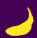
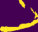

In [8]:
display_catalog(storms, 5)

The `storms` object is a `pandas.DataFrame`, with rows corresponding to different identified AR storm events that made landfall. The `data_array` column contains binary-valued `xarray.DataArray` masks of the full spatiotemporal footprint of the storm. Note, we must use the `display_catalog` function from our local `display_utils` module to view the dataframe. Otherwise, if one attempts to print the dataframe as usual, the `data_array` column will be filled with string representations of the masks which (1) take forever to render and (2) are unpleasant to look at.

In [9]:
storms.loc[1].data_array

<xarray.DataArray 'clust' (time: 15, lat: 72, lon: 71)> Size: 77kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(15, 72, 71), dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 120B 1980-01-02 ... 1980-01-03T18:00:00
  * lat      (lat) float64 576B -74.5 -74.0 -73.5 -73.0 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 568B -119.4 -118.8 -118.1 ... -76.88 -76.25 -75.62

Organizing the catalog in this way means we can appeal to `pandas` very powerful and compact API to compute relevant storm quantities.

## Filling in Storm Attributes and Impacts

Now let's put these masks to good use and start grabbing interesting quantities associated with each storm. There are two kinds of quantities we can compute, ones which need reanalysis data (geographic attributes, when and where, etc.) and ones which don't (atmospheric quantities). We'll start with computing quantities that don't yet require reanalysis data and finish with a fully cloud-based workflow to compute quantities that do require reanalysis.

### Geographic Quantities

Let's start with computing geographic attributes of each landfalling storm. This includes the following quantities:
+ `duration`: how long did it last
+ `start_date`: when did the storm first appear
+ `end_date`: when did it dissipate

Helper functions to compute each of these attributes given a storm's `xarray.DataArray` can be found in the `attributes_utils` module.

In [10]:
storms['duration'] = storms['data_array'].apply(compute_duration)
storms['start_date'] = storms['data_array'].apply(add_start_date)
storms['end_date'] = storms['data_array'].apply(add_end_date)

Let's take a look at what we were able to create.

,data_array,is_landfalling,duration,start_date,end_date
cluster,,,,,
1,,True,45,1980-01-02 00:00:00,1980-01-03 18:00:00
4,,True,42,1980-01-06 18:00:00,1980-01-08 12:00:00
5,,True,3,1980-01-08 12:00:00,1980-01-08 12:00:00
6,,True,3,1980-01-09 15:00:00,1980-01-09 15:00:00
11,,True,6,1980-01-11 12:00:00,1980-01-11 15:00:00

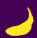
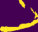

In [11]:
display_catalog(storms, 5)

Let's save our intermediate output.

In [12]:
storms.to_hdf('../output/data_products/storms_setting_virtual.h5', key='df')

/tmp/ipykernel_36481/2600884579.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['data_array'], dtype='object')]

  storms.to_hdf('../output/data_products/storms_setting_virtual.h5', key='df')


### Atmospheric Quantities

Now for the more interesting part, let's compute atmospheric characteristics and attributes for each storm. This includes things like their landfalling moisture content, wind speeds, as well as their impacts, like cumulative snowfall on the ice sheet or maximum surface temperature anomaly. In this tutorial, we will be focusing on gathering three quantities related to AR impacts: maxmimum surface temperature anomaly underneath the footprint over the AIS, cumulative snowfall on the AIS, and cumulative rainfall on the AIS.

We'll be using MERRA-2 reanalysis data to get these quantities. Of course, one might just execute this workflow by loading it up from disk at some local file system you have access to, but that's not very reproducible, accessible, or open! Instead, we'll be streaming MERRA-2 from AWS S3 buckets using `earthaccess`, a workflow that is much more reproducible, accessible, open, and lightweight!

:::{attention}

To access MERRA-2 data in the cloud, you'll need to first create a NASA Earthdata account and create the relevant [Earthdata prerequisite files](https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Generate_Earthdata_Prerequisite_Files.ipynb), most notably the `.netrc` file with your Earthdata login credentials. You will also need to be in the AWS `us-west-2` region to stream from s3. If you are running this notebook on CryoCloud, you are in `us-west-2`.

:::

In [13]:
data_dois = {'climatology': '10.5067/5ESKGQTZG7FO',
             'T2M': '10.5067/3Z173KIE2TPD',
             'PRECIP': '10.5067/Q5GVUVUIVGO7'}

#### Climatology

To compute surface temperature anomaly, we'll need to compute a climatology. We'll compute the climatology of both of these variables via streaming first. The climatology is computed by taking monthly averaged dataset of our variables from MERRA-2, and then further averaging those across the years. Since the original Wille (2021) catalog on which ours is based goes from 1980 to 2022, we will be computing monthly averages over this range.

:::{attention}
Either we can run the next cell to create the climatology dataset, which should take about 20 minutes to do. Or, you could run this just once, save it, and just load it up from disk for future runs. If you don't want to wait, we've already stored it in the `/output/data_products/` directory of this repo, so you can skip this cell and run the next one.
:::

In [14]:
# grab granules for monthly data
#granule_lst = earthaccess.search_data(doi=data_dois['climatology'], 
#                                  temporal=('1980-01-01', '2022-12-31'))
# open pointers to nc4 stored in AWS S3 buckets
#pointers = earthaccess.open(granule_lst, show_progress=False)

#monthly_means = xr.open_mfdataset(pointers)
#monthly_means = monthly_means[['T2M']]
#climatology_ds = monthly_means.groupby(monthly_means.time.dt.month).mean().compute()
#climatology_ds = climatology_ds.assign_coords(lat=climatology_ds.lat.round(5), lon=climatology_ds.lon.round(5))
#climatology_ds.to_netcdf('output/data_products/climatology.nc4')

In [15]:
climatology_ds = xr.load_dataset('../output/data_products/climatology.nc4')

#### Streaming Setup

We first need to virtualize the datasets we will need for our analysis. We'll be extracting data from 2 MERRA-2 datasets, one that has 2m-temperature data, and another with precip data. We don't need all of the variables from each dataset, so let's just virtualize the datasets with only those variables we need.

Because the full granule list spans roughly 40 years and ~15,000 granules per dataset, virtualizing the entire list in one call can be fragile: the in-memory reference manifest grows large, and a single transient failure forces you to start over with no checkpoint. Instead, we virtualize in **batches** of granules, writing a kerchunk parquet to disk after each batch. This caps peak memory, gives us a progress trail in the log, and makes the workflow resumable — if batch N dies, on restart we skip the batches that are already on disk and continue from N.

After all batches are written, we combine them into a single lazy `xarray.Dataset` per MERRA-2 dataset using `xarray.concat` over the per-batch reference filesystems. This concatenation is lazy: it stitches coordinates without reading any chunk data, so downstream Ray workers still stream chunks on demand.

In [16]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('../output/logs/streaming_progress_virtualization.log')
    ]
)
logging.info("Starting streaming workflow...")

2026-05-12 21:59:56,585 - INFO - Starting streaming workflow...


In [17]:
# find first and last dates of storms across 40 year archive of ARs
# add one day to the last storm because precip is also counted as falling 24 hours later
first = storms.start_date.min()
last = storms.end_date.max() + timedelta(days=1)

In [18]:
storms.start_date

cluster
1.0     1980-01-02 00:00:00
4.0     1980-01-06 18:00:00
5.0     1980-01-08 12:00:00
6.0     1980-01-09 15:00:00
11.0    1980-01-11 12:00:00
                ...        
269.0   1981-05-13 03:00:00
274.0   1981-05-14 06:00:00
283.0   1981-05-22 12:00:00
284.0   1981-05-22 15:00:00
285.0   1981-06-03 21:00:00
Name: start_date, Length: 100, dtype: datetime64[ns]

In [19]:
logging.info("Finding temperature and precipitation dataset granules...")

# lists of granules from both MERRA datasets
granule_lst_temp = earthaccess.search_data(doi=data_dois['T2M'],
                                  temporal=(f'{first.year}-{first.month}-{first.day}',
                                            f'{last.year}-{last.month}-{last.day}'))

granule_lst_precip = earthaccess.search_data(doi=data_dois['PRECIP'],
                                  temporal=(f'{first.year}-{first.month}-{first.day}',
                                            f'{last.year}-{last.month}-{last.day}'))

logging.info(f"Granules found: T2M={len(granule_lst_temp)}, PRECIP={len(granule_lst_precip)}")


2026-05-12 22:00:12,458 - INFO - Finding temperature and precipitation dataset granules...


/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/search.py:955: FutureWarning: As of version 1.0, `DataCollection.concept_id` will be accessed as an attribute; e.g. use `DataCollection.concept_id` **not** `DataCollection.concept_id()`
  concept_id = collection[0].concept_id()


2026-05-12 22:00:17,949 - INFO - Granules found: 521


/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


2026-05-12 22:00:21,973 - INFO - Granules found: 521
2026-05-12 22:00:22,636 - INFO - Granules found: T2M=521, PRECIP=521


In [20]:
# Batched virtualization: write one kerchunk parquet per batch of granules.
# This caps peak memory, logs progress per batch, and makes the workflow resumable.

BATCH_SIZE = 50  # tune: smaller = safer memory, more I/O overhead. ~1.4 yrs of daily granules at 500.
TEMP_BATCH_DIR = Path('../output/data_products/temp_batches')
PRECIP_BATCH_DIR = Path('../output/data_products/precip_batches')
TEMP_BATCH_DIR.mkdir(parents=True, exist_ok=True)
PRECIP_BATCH_DIR.mkdir(parents=True, exist_ok=True)


def virtualize_in_batches(granule_lst, keep_vars, batch_dir, batch_size, label):
    """Virtualize a granule list in batches, checkpointing each batch to parquet.

    Skips batches whose parquet already exists (resumability). Returns the list
    of parquet paths in temporal order.
    """
    n = len(granule_lst)
    n_batches = (n + batch_size - 1) // batch_size
    logging.info(f"{label}: {n} granules -> {n_batches} batches of up to {batch_size}")

    parquet_paths = []
    for b in range(n_batches):
        out_path = batch_dir / f'batch_{b:04d}.parquet'
        parquet_paths.append(out_path)

        if out_path.exists():
            logging.info(f"{label}: batch {b+1}/{n_batches} already exists, skipping")
            continue

        start = b * batch_size
        end = min(start + batch_size, n)
        batch_granules = granule_lst[start:end]

        logging.info(f"{label}: virtualizing batch {b+1}/{n_batches} (granules {start}:{end})")
        try:
            vds = earthaccess.virtualize(batch_granules, access='direct', concat_dim='time')
            vds_subset = vds[keep_vars]
            vds_subset.virtualize.to_kerchunk(str(out_path), format='parquet')
            del vds, vds_subset
            logging.info(f"{label}: wrote {out_path.name}")
        except Exception as e:
            logging.error(f"{label}: batch {b+1}/{n_batches} failed: {e!r}")
            raise

    return parquet_paths


logging.info('Virtualizing the temperature dataset in batches...')
temp_parquet_paths = virtualize_in_batches(
    granule_lst_temp,
    keep_vars=['T2M'],
    batch_dir=TEMP_BATCH_DIR,
    batch_size=BATCH_SIZE,
    label='T2M',
)
logging.info('Finished virtualizing the temperature dataset!')


2026-05-12 22:00:46,063 - INFO - Virtualizing the temperature dataset in batches...
2026-05-12 22:00:46,064 - INFO - T2M: 521 granules -> 11 batches of up to 50
2026-05-12 22:00:46,065 - INFO - T2M: virtualizing batch 1/11 (granules 0:50)
2026-05-12 22:01:02,155 - INFO - T2M: wrote batch_0000.parquet
2026-05-12 22:01:02,156 - INFO - T2M: virtualizing batch 2/11 (granules 50:100)
2026-05-12 22:01:17,800 - INFO - T2M: wrote batch_0001.parquet
2026-05-12 22:01:17,801 - INFO - T2M: virtualizing batch 3/11 (granules 100:150)
2026-05-12 22:01:34,457 - INFO - T2M: wrote batch_0002.parquet
2026-05-12 22:01:34,502 - INFO - T2M: virtualizing batch 4/11 (granules 150:200)
2026-05-12 22:01:51,053 - INFO - T2M: wrote batch_0003.parquet
2026-05-12 22:01:51,054 - INFO - T2M: virtualizing batch 5/11 (granules 200:250)
2026-05-12 22:02:07,218 - INFO - T2M: wrote batch_0004.parquet
2026-05-12 22:02:07,219 - INFO - T2M: virtualizing batch 6/11 (granules 250:300)
2026-05-12 22:02:23,492 - INFO - T2M: wrot

In [ ]:
logging.info('Virtualizing the precip dataset in batches...')
precip_parquet_paths = virtualize_in_batches(
    granule_lst_precip,
    keep_vars=['PRECLS', 'PRECCU', 'PRECSN'],
    batch_dir=PRECIP_BATCH_DIR,
    batch_size=BATCH_SIZE,
    label='PRECIP',
)
logging.info('Finished virtualizing the precip dataset!')


That concludes our effort to virtualize the data! This is a one-time cost: once the per-batch parquet files exist on disk, subsequent runs of this notebook will skip the virtualization step entirely (each batch checks for its parquet before doing work). We now load up the per-batch parquet files and concatenate them along the time dimension into a single lazy `xarray.Dataset` per MERRA-2 dataset.

To load the data, we authenticate with S3 to access data stored in the buckets (otherwise, we'll get a credentialling error if we attempt to just start using xarray operations). The code below is adapted from [here](https://gist.github.com/betolink/82f6dd6f2a952dc03edc19bd6dee12ae).

In [21]:
daac_fs = earthaccess.get_s3_filesystem(daac='GES_DISC')
# Capture S3 storage options once; this dict is small and picklable, safe to send to workers.
S3_STORAGE_OPTIONS = dict(daac_fs.storage_options)


def open_batch(parquet_path, storage_options):
    """Open a single kerchunk parquet reference as a lazy xarray Dataset."""
    fs = fsspec.filesystem(
        "reference",
        fo=str(parquet_path),
        remote_protocol="s3",
        asynchronous=True,
        remote_options={"asynchronous": True, **storage_options},
    )
    store = zarr.storage.FsspecStore(fs, read_only=True)
    return xr.open_zarr(store, consolidated=False)


def open_combined(parquet_paths, storage_options=None):
    """Open per-batch kerchunk parquet refs as one time-concatenated lazy xarray Dataset.

    `xr.concat` over zarr-backed datasets is cheap: it stitches coordinates without
    reading chunk data. Pass `storage_options=S3_STORAGE_OPTIONS` to make this safe
    to call inside Ray workers (the global won't exist there).
    """
    if storage_options is None:
        storage_options = S3_STORAGE_OPTIONS
    datasets = [open_batch(p, storage_options) for p in parquet_paths]
    return xr.concat(datasets, dim='time')


# Convert paths to plain strings so they pickle cleanly into worker tasks.
temp_parquet_strs = [str(p) for p in temp_parquet_paths]
#precip_parquet_strs = [str(p) for p in precip_parquet_paths]

# Build local handles for any inspection you want to do in the notebook itself.
# These are NOT what gets sent to workers; workers build their own from the path lists.
temp_ds = open_combined(temp_parquet_strs)
#precip_ds = open_combined(precip_parquet_strs)


2026-05-12 22:03:47,400 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0000.parquet
2026-05-12 22:03:47,557 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0000.parquet
2026-05-12 22:03:47,558 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0000.parquet
2026-05-12 22:03:47,560 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0001.parquet
2026-05-12 22:03:47,587 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0001.parquet
2026-05-12 22:03:47,588 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0001.parquet
2026-05-12 22:03:47,590 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0002.parquet
2026-05-12 22:03:47,617 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0002.parquet
2026-05-12 22:03

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.

2026-05-12 22:03:47,761 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0007.parquet
2026-05-12 22:03:47,762 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0007.parquet
2026-05-12 22:03:47,763 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0008.parquet
2026-05-12 22:03:47,790 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0008.parquet
2026-05-12 22:03:47,791 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0008.parquet
2026-05-12 22:03:47,793 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0009.parquet
2026-05-12 22:03:47,818 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0009.parquet
2026-05-12 22:03:47,819 - INFO - Open lazy reference dict from URL ../output/data_products/temp_batches/batch_0009.parquet
2026-05-12 22:03

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.

Now, `precip_ds` and `temp_ds` are Datasets that we can apply our masks to! Now, onto our last step of preparation for the loop. We will be streaming quantities from a MERRA-2 dataset and extracting summary statistics on a storm-by-storm basis, executing the loop by parallelizing using Ray. To ensure workers receive a roughly equal amount of work, we first sort the storms in order of decreasing duration, as storms with longer durations and larger spatiotemporal footprints require more time to compute their quantities.

In [22]:
sorted_storms = storms.sort_values(by='duration', ascending=False)

So each worker has a sufficient amount of work for each iteration of the parallel loop, we will also split the full list of storms into chunks of fixed size. Each worker will then take a chunk of storms to process. Below, we define global variables for how many workers and how many chunks we would like to use.

In [24]:
NUM_WORKERS = 5
CHUNK_SIZE = 5

The full streaming workflow may take a few hours to execute, depending on how many storms and how many quantities you are dealing with. We recommend using `jupyter-keepalive` to keep your Jupyter session alive even after exiting. Instructions on how to use this feature can be found [here](https://github.com/minrk/jupyter-keepalive). This functionality is already included in our image environment, so there is no need to install it. 

However, once you leave the notebook, even though the server is still alive and the computation is still running, output to track the computation will no longer be rendered in the notebook. To track the computation, we will set up a logger that will output the progress of our computations to `/output/logs/`.

#### 2m-Temperature Anomaly

In our workflow, we go through each storm and execute a function called `compute_summaries_virtual` on each storm. `compute_summaries_virtual` computes scalar summaries of all desired variables from the particular MERRA-2 dataset we are
working with. To indicate which variables and which scalar summaries you would like, you must pass in a dictionary of dictionaries which we will call `func_vars_dict`. The keys of the outer dictionary are the variable names in the MERRA-2 dataset we'd like to compute aggregates of, and the values are themselves dictionaries where each item represents some desired aggregation function of that variable. The provided keys are the names of that scalar summary that will appear in the resulting dataset.

In this way, when we stream a set of days of data for a particular storm, we compute all relevant quantities on that storm before throwing the data away and re-streaming for the next storm.

First, we initialize our Ray cluster with the number of CPUs we wish to parallelize over, 1 worker per CPU. For each MERRA-2 dataset we stream from, we will be reinitializing and then closing the cluster. This is to reduce the memory footprint of the computation, ensuring a fresh start after each computation is complete.

In [25]:
ray.init(num_cpus=NUM_WORKERS, logging_level='ERROR', 
         _metrics_export_port=-1, include_dashboard=False, 
         log_to_driver=False, runtime_env={'py_modules': [artools.attribute_utils, artools.loading_utils]})

# put the climatologies and cell areas in the ray object store
climatology_ref = ray.put(climatology_ds)
cell_areas_ref = ray.put(cell_areas)

/srv/conda/envs/notebook/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [26]:
@ray.remote(max_calls=1)
def compute_chunk_summaries_from_paths(chunk_lst, parquet_paths, storage_options,
                                       func_vars_dict, cell_areas,
                                       half_hour=False, climatology_ds=None):
    # Imports live INSIDE the function so Ray's cloudpickle doesn't try to
    # serialize the module objects as captured globals (zarr 3.x's VerboseModule
    # is not picklable). The worker process re-imports cheaply.
    import fsspec
    import zarr
    import xarray as xr
    from artools.compute_attributes_streaming_virtual import compute_summaries_virtual

    datasets = []
    for p in parquet_paths:
        fs = fsspec.filesystem(
            "reference",
            fo=p,
            remote_protocol="s3",
            asynchronous=True,
            remote_options={"asynchronous": True, **storage_options},
        )
        store = zarr.storage.FsspecStore(fs, read_only=True)
        datasets.append(xr.open_zarr(store, consolidated=False))
    obs_ds = xr.concat(datasets, dim='time')

    summaries_lst = []
    for _, storm in chunk_lst.iterrows():
        summaries_lst.append(
            compute_summaries_virtual(storm.data_array, obs_ds, func_vars_dict,
                                      cell_areas, half_hour, climatology_ds)
        )
    return summaries_lst


func_vars_dict = {'T2M': {'max_T2M_anomaly_ais': lambda storm_da, var_da, area_da:
                              compute_max_intensity(storm_da, var_da, area_da, ais_mask)}}

func_vars_dict_ref = ray.put(func_vars_dict)
temp_paths_ref = ray.put(temp_parquet_strs)
storage_opts_ref = ray.put(S3_STORAGE_OPTIONS)

data_doi = data_dois['T2M']
results_T2M = []

chunks = [sorted_storms.iloc[i:i + CHUNK_SIZE] for i in range(0, sorted_storms.shape[0], CHUNK_SIZE)]

logging.info(f"Starting T2M computations in chunks...")

chunk_refs = [
    compute_chunk_summaries_from_paths.remote(
        chunk,
        temp_paths_ref,
        storage_opts_ref,
        func_vars_dict_ref,
        cell_areas_ref,
        climatology_ds=climatology_ref,
    ) for chunk in chunks
]

for j, ref in enumerate(chunk_refs):
    results = ray.get(ref)
    results_T2M.extend(results)
    chunk_refs[j] = None
    logging.info(f"T2M: Finished chunk {j + 1}/{len(chunks)}")

logging.info("T2M computations complete.")


2026-05-12 22:04:29,581 - INFO - Starting T2M computations in chunks...
2026-05-12 22:04:58,113 - INFO - T2M: Finished chunk 1/20
2026-05-12 22:04:58,114 - INFO - T2M: Finished chunk 2/20
2026-05-12 22:04:58,115 - INFO - T2M: Finished chunk 3/20
2026-05-12 22:04:58,116 - INFO - T2M: Finished chunk 4/20
2026-05-12 22:04:58,117 - INFO - T2M: Finished chunk 5/20
2026-05-12 22:05:06,209 - INFO - T2M: Finished chunk 6/20
2026-05-12 22:05:11,448 - INFO - T2M: Finished chunk 7/20
2026-05-12 22:05:11,449 - INFO - T2M: Finished chunk 8/20
2026-05-12 22:05:17,206 - INFO - T2M: Finished chunk 9/20
2026-05-12 22:05:17,845 - INFO - T2M: Finished chunk 10/20
2026-05-12 22:05:22,777 - INFO - T2M: Finished chunk 11/20
2026-05-12 22:05:29,345 - INFO - T2M: Finished chunk 12/20
2026-05-12 22:05:29,346 - INFO - T2M: Finished chunk 13/20
2026-05-12 22:05:36,783 - INFO - T2M: Finished chunk 14/20
2026-05-12 22:05:38,890 - INFO - T2M: Finished chunk 15/20
2026-05-12 22:05:40,172 - INFO - T2M: Finished chunk

In [27]:
# construct dataframe to concatenate into the original dataframe
labels = [key for quantity_dict in func_vars_dict.values() for key in quantity_dict.keys()]
df_T2M = pd.DataFrame(results_T2M, columns=labels, index=sorted_storms.index)
df_T2M_original_order = df_T2M.loc[storms.index]
df_T2M_original_order.to_csv('../output/data_products/results_T2M_virtual.csv')
logging.info("T2M results saved!")

2026-05-12 22:06:21,435 - INFO - T2M results saved!


In [28]:
ray.shutdown()

#### Snowfall and Rainfall

Snowfall and rainfall come from the same MERRA-2 dataset as poleward integrated vapor transport. However, we treat them separately because precipitation quantities are computed not on the spatiotemporal footprint of the mask as the previous quantities, but an augmented mask where even if the AR has left a pixel at a particular time, that pixel is still considered part of the AR footprint for the next 24 hours. Because of this extra preprocessing, we pass a `precip_func` function, the aggregation function we wish to use, into a summary computation function particular to this case (`compute_precip_summaries`).

In [ ]:
ray.init(num_cpus=NUM_WORKERS, logging_level='ERROR', 
         _metrics_export_port=-1, include_dashboard=False, 
         log_to_driver=False, runtime_env={'py_modules': [artools.attribute_utils, artools.loading_utils]})

# put the climatologies and cell areas in the ray object store
climatology_ref = ray.put(climatology_ds)
cell_areas_ref = ray.put(cell_areas)

In [ ]:
data_doi = data_dois['PRECIP']

# storing the aggregation function for precip in the ray store
def precip_func(storm_da, var_da, area_da):
    return compute_cumulative(storm_da, var_da, area_da, ais_mask)
precip_func_ref = ray.put(precip_func)

In [ ]:
@ray.remote(max_calls=1)
def compute_precip_chunk_summaries_from_paths(chunk_lst, parquet_paths, storage_options,
                                              cell_areas, agg_func):
    import fsspec
    import zarr
    import xarray as xr
    from artools.compute_attributes_streaming_virtual import compute_precip_summaries_virtual

    datasets = []
    for p in parquet_paths:
        fs = fsspec.filesystem(
            "reference",
            fo=p,
            remote_protocol="s3",
            asynchronous=True,
            remote_options={"asynchronous": True, **storage_options},
        )
        store = zarr.storage.FsspecStore(fs, read_only=True)
        datasets.append(xr.open_zarr(store, consolidated=False))
    obs_ds = xr.concat(datasets, dim='time')

    summaries_lst = []
    for _, storm in chunk_lst.iterrows():
        summaries_lst.append(
            compute_precip_summaries_virtual(storm.data_array, obs_ds,
                                             cell_areas, agg_func)
        )
    return summaries_lst


results_precip = []

precip_paths_ref = ray.put(precip_parquet_strs)
storage_opts_ref = ray.put(S3_STORAGE_OPTIONS)

chunks = [sorted_storms.iloc[i:i + CHUNK_SIZE] for i in range(0, sorted_storms.shape[0], CHUNK_SIZE)]

logging.info(f"Starting Precipitation computations in chunks...")

chunk_refs = [
    compute_precip_chunk_summaries_from_paths.remote(
        chunk,
        precip_paths_ref,
        storage_opts_ref,
        cell_areas_ref,
        precip_func_ref,
    ) for chunk in chunks
]

for j, ref in enumerate(chunk_refs):
    results = ray.get(ref)
    results_precip.extend(results)
    chunk_refs[j] = None
    logging.info(f"Precip: Finished chunk {j + 1}/{len(chunks)}")

logging.info("Precipitation computations complete.")


In [ ]:
# construct dataframe to concatenate into the original dataframe
labels = ['cumulative_rainfall_ais', 'cumulative_snowfall_ais']
df_precip = pd.DataFrame(results_precip, columns=labels, index=sorted_storms.index)
df_precip_original_order = df_precip.loc[storms.index]
df_precip_original_order.to_csv('../output/data_products/results_precip_virtual.csv')
logging.info("Precip results saved!")

In [ ]:
ray.shutdown()